NLP PREPROCESSING FOR 50K MOVIE REVIEWS - SENTIMENT **ANALYSIS**

In [2]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "IMDB Dataset.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews",
  file_path,
)

print("First 5 records:", df.head())

/tmp/ipykernel_687/3310047898.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
First 5 records:                                               review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [3]:
import pandas as pd
import numpy as np
import re
import string
import nltk
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer


In [4]:
# Download required NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')

print("✓ All libraries installed and imported successfully!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...


✓ All libraries installed and imported successfully!


[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


In [6]:
df


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [7]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [9]:
df.shape

(50000, 2)

In [10]:
print(df.isnull().sum())


review       0
sentiment    0
dtype: int64


In [11]:
#TML tags like <p>, <br>, <div> are common in web-scraped reviews.so remove them

def remove_html_tags(text):
    """
    Removes HTML tags from text using BeautifulSoup
    Example: "<p>Great movie!</p>" → "Great movie!"
    """
    soup = BeautifulSoup(text, "html.parser")
    return soup.get_text()

In [13]:
df['review_no_html'] = df['review'].apply(remove_html_tags)

In [15]:
print(df['review_no_html'])

0        One of the other reviewers has mentioned that ...
1        A wonderful little production. The filming tec...
2        I thought this was a wonderful way to spend ti...
3        Basically there's a family where a little boy ...
4        Petter Mattei's "Love in the Time of Money" is...
                               ...                        
49995    I thought this movie did a down right good job...
49996    Bad plot, bad dialogue, bad acting, idiotic di...
49997    I am a Catholic taught in parochial elementary...
49998    I'm going to have to disagree with the previou...
49999    No one expects the Star Trek movies to be high...
Name: review_no_html, Length: 50000, dtype: object


In [16]:
# Display before and after
print("BEFORE removing HTML tags:")
print(df['review'].iloc[0])
print("\nAFTER removing HTML tags:")
print(df['review_no_html'].iloc[0])

BEFORE removing HTML tags:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of

In [17]:
# URLs don't carry sentiment information

def remove_urls(text):
    """
    Removes URLs from text using regex
    Example: "Check this http://example.com" → "Check this "
    """
    # Pattern matches http://, https://, www., and email addresses
    text = re.sub(r'http\S+|www.\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\S+@\S+', '', text)  # Remove email addresses
    return text

df['review_no_urls'] = df['review_no_html'].apply(remove_urls)

print("BEFORE removing URLs:")
print(df['review_no_html'].iloc[0])
print("\nAFTER removing URLs:")
print(df['review_no_urls'].iloc[0])

BEFORE removing URLs:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.I would say the main appeal of the show is due to the fact that it goes

In [19]:
text1 = "Check this http://example.com"
text1 = re.sub(r'http\S+|www.\S+|https\S+', '', text, flags=re.MULTILINE)
print(text1)

Check this 


In [22]:
text2 = "Hey rajan here ,this is my profile http://rajanG.com"
print(remove_urls(text2))

Hey rajan here ,this is my profile 


In [23]:
def to_lowercase(text):
    """
    Converts all text to lowercase
    Example: "GOOD Movie!" → "good movie!"
    """
    return text.lower()

df['review_lower'] = df['review_no_urls'].apply(to_lowercase)


In [24]:
df.head(

)

,review,sentiment,review_no_html,review_no_urls,review_lower
0,One of the other reviewers has mentioned that ...,positive,One of the other reviewers has mentioned that ...,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,A wonderful little production. The filming tec...,A wonderful little production. The filming tec...,a wonderful little production. the filming tec...
2,I thought this was a wonderful way to spend ti...,positive,I thought this was a wonderful way to spend ti...,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,Basically there's a family where a little boy ...,Basically there's a family where a little boy ...,basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,"Petter Mattei's ""Love in the Time of Money"" is...","Petter Mattei's ""Love in the Time of Money"" is...","petter mattei's ""love in the time of money"" is..."


In [25]:
print(df.iloc[0])

review            One of the other reviewers has mentioned that ...
sentiment                                                  positive
review_no_html    One of the other reviewers has mentioned that ...
review_no_urls    One of the other reviewers has mentioned that ...
review_lower      one of the other reviewers has mentioned that ...
Name: 0, dtype: object


In [26]:
# Punctuation marks usually don't carry sentiment (except ! and ? sometimes)

def remove_punctuation(text):
    """
    Removes all punctuation marks
    Example: "Great movie!!!" → "Great movie"
    """
    translator = str.maketrans('', '', string.punctuation)
    return text.translate(translator)

df['review_no_punct'] = df['review_lower'].apply(remove_punctuation)

In [27]:
# Numbers typically don't contribute to sentiment

def remove_numbers(text):
    """
    Removes all numeric digits
    Example: "Rated 8/10" → "Rated /"
    """
    text = re.sub(r'\d+', '', text)
    return text

df['review_no_numbers'] = df['review_no_punct'].apply(remove_numbers)

In [28]:
# Clean up multiple spaces, tabs, and newlines

def remove_extra_whitespace(text):
    """
    Removes extra whitespace, tabs, and newlines
    Example: "Great   movie" → "Great movie"
    """
    text = re.sub(r'\s+', ' ', text)  # Replace multiple spaces with single space
    text = text.strip()  # Remove leading/trailing spaces
    return text

df['review_clean'] = df['review_no_numbers'].apply(remove_extra_whitespace)

In [29]:
# Common words like "the", "is", "at" that don't carry sentiment

def remove_stopwords(text):
    """
    Removes English stop words
    Example: "the movie was great" → "movie great"
    """
    stop_words = set(stopwords.words('english'))
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

df['review_no_stopwords'] = df['review_clean'].apply(remove_stopwords)

In [30]:
# Split text into individual words (tokens)

def tokenize_text(text):
    """
    Splits text into individual word tokens
    Example: "great movie" → ["great", "movie"]
    """
    tokens = word_tokenize(text)
    return tokens

df['tokens'] = df['review_no_stopwords'].apply(tokenize_text)


In [34]:
text3 = "hey whats up???? what aare you doing these days!!, Long time no see haannnnn!!!"
print(tokenize_text(text3))


['hey', 'whats', 'up', '?', '?', '?', '?', 'what', 'aare', 'you', 'doing', 'these', 'days', '!', '!', ',', 'Long', 'time', 'no', 'see', 'haannnnn', '!', '!', '!']


 **LEMMATIZATION**

In [35]:
# Convert words to their base/dictionary form
# Example: "loved", "loving", "loves" → "love"

def lemmatize_tokens(tokens):
    """
    Converts words to their base form (lemma)
    Example: ["loved", "movies"] → ["love", "movie"]
    """
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return lemmatized_tokens

df['lemmatized_tokens'] = df['tokens'].apply(lemmatize_tokens)

In [36]:
text4 = "hey whats up???? what aare you doing these days!!, Long time no see haannnnn!!!"
print(lemmatize_tokens(text4))

['h', 'e', 'y', ' ', 'w', 'h', 'a', 't', 's', ' ', 'u', 'p', '?', '?', '?', '?', ' ', 'w', 'h', 'a', 't', ' ', 'a', 'a', 'r', 'e', ' ', 'y', 'o', 'u', ' ', 'd', 'o', 'i', 'n', 'g', ' ', 't', 'h', 'e', 's', 'e', ' ', 'd', 'a', 'y', 's', '!', '!', ',', ' ', 'L', 'o', 'n', 'g', ' ', 't', 'i', 'm', 'e', ' ', 'n', 'o', ' ', 's', 'e', 'e', ' ', 'h', 'a', 'a', 'n', 'n', 'n', 'n', 'n', '!', '!', '!']


In [37]:
# Convert token list back to string for vectorization

def join_tokens(tokens):
    """
    Joins tokens back into a single string
    Example: ["great", "movie"] → "great movie"
    """
    return ' '.join(tokens)

df['review_final'] = df['lemmatized_tokens'].apply(join_tokens)

print("Final preprocessed review:")
print(df['review_final'].iloc[0])

Final preprocessed review:
one reviewer mentioned watching oz episode youll hooked right exactly happened methe first thing struck oz brutality unflinching scene violence set right word go trust show faint hearted timid show pull punch regard drug sex violence hardcore classic use wordit called oz nickname given oswald maximum security state penitentary focus mainly emerald city experimental section prison cell glass front face inwards privacy high agenda em city home manyaryans muslim gangsta latino christian italian irish moreso scuffle death stare dodgy dealing shady agreement never far awayi would say main appeal show due fact go show wouldnt dare forget pretty picture painted mainstream audience forget charm forget romanceoz doesnt mess around first episode ever saw struck nasty surreal couldnt say ready watched developed taste oz got accustomed high level graphic violence violence injustice crooked guard wholl sold nickel inmate wholl kill order get away well mannered middle clas

**COMPLETE PREPROCESSING PIPELINE (ALL-IN-ONE FUNCTION)**

In [38]:
def preprocess_review(text):
    """
    Complete preprocessing pipeline in one function
    Applies all steps: HTML removal, URL removal, lowercasing,
    punctuation removal, number removal, whitespace cleanup,
    stopword removal, tokenization, and lemmatization
    """
    # Step 1: Remove HTML tags
    soup = BeautifulSoup(text, "html.parser")
    text = soup.get_text()

    # Step 2: Remove URLs and emails
    text = re.sub(r'http\S+|www.\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\S+@\S+', '', text)

    # Step 3: Convert to lowercase
    text = text.lower()

    # Step 4: Remove punctuation
    translator = str.maketrans('', '', string.punctuation)
    text = text.translate(translator)

    # Step 5: Remove numbers
    text = re.sub(r'\d+', '', text)

    # Step 6: Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 7: Remove stopwords
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    text = ' '.join(words)

    # Step 8: Tokenize
    tokens = word_tokenize(text)

    # Step 9: Lemmatize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    # Step 10: Join back to string
    text = ' '.join(tokens)

    return text

# Apply to entire dataset
df['review_preprocessed'] = df['review'].apply(preprocess_review)

print("\n✓ Complete preprocessing applied to all reviews!")
print(f"Dataset shape: {df.shape}")
print("\nOriginal review:")
print(df['review'].iloc[0])
print("\nPreprocessed review:")
print(df['review_preprocessed'].iloc[0])


✓ Complete preprocessing applied to all reviews!
Dataset shape: (50000, 13)

Original review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agre

**SAVE PREPROCESSED DATA**

In [39]:
# Save your cleaned dataset for model training

# Save to CSV
df.to_csv('movie_reviews_preprocessed.csv', index=False)
print("✓ Preprocessed data saved to 'movie_reviews_preprocessed.csv'")

# Display final dataset structure
print("\nFinal Dataset Columns:")
print(df.columns.tolist())
print("\nSample of final preprocessed data:")
display(df[['review', 'review_preprocessed', 'sentiment']].head())



✓ Preprocessed data saved to 'movie_reviews_preprocessed.csv'

Final Dataset Columns:
['review', 'sentiment', 'review_no_html', 'review_no_urls', 'review_lower', 'review_no_punct', 'review_no_numbers', 'review_clean', 'review_no_stopwords', 'tokens', 'lemmatized_tokens', 'review_final', 'review_preprocessed']

Sample of final preprocessed data:


,review,review_preprocessed,sentiment
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...,positive
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,positive
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,positive
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...,positive


**REMOVE EMOJIS**

In [40]:
# If your reviews contain emojis, you can remove or convert them

def remove_emojis(text):
    """
    Removes emoji characters from text
    """
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

In [41]:
emoji_text = "The story feels copied from better films like Wreck-It Ralph and Inside Out 🤖. It relies too much on boring brand names and cheap jokes instead of real fun 📉."

print(remove_emojis(emoji_text))

The story feels copied from better films like Wreck-It Ralph and Inside Out 🤖. It relies too much on boring brand names and cheap jokes instead of real fun .


**CHECK PREPROCESSING QUALITY**

In [42]:
# Verify your preprocessing worked correctly

print("=" * 60)
print("PREPROCESSING VERIFICATION")
print("=" * 60)

# Check dataset size
print(f"\nTotal reviews: {len(df)}")

# Check for empty reviews after preprocessing
empty_reviews = df[df['review_preprocessed'].str.len() == 0]
print(f"Empty reviews after preprocessing: {len(empty_reviews)}")

# Check average review length before and after
avg_length_before = df['review'].str.len().mean()
avg_length_after = df['review_preprocessed'].str.len().mean()
print(f"\nAverage review length BEFORE: {avg_length_before:.2f} characters")
print(f"Average review length AFTER: {avg_length_after:.2f} characters")

# Sample before/after comparison
print("\n" + "=" * 60)
print("SAMPLE BEFORE/AFTER COMPARISON")
print("=" * 60)
for i in range(3):
    print(f"\nReview {i+1}:")
    print(f"ORIGINAL: {df['review'].iloc[i]}")
    print(f"PREPROCESSED: {df['review_preprocessed'].iloc[i]}")
    print("-" * 60)

print("\n✓ Preprocessing complete! Ready for sentiment analysis model training.")

PREPROCESSING VERIFICATION

Total reviews: 50000
Empty reviews after preprocessing: 0

Average review length BEFORE: 1309.43 characters
Average review length AFTER: 820.03 characters

SAMPLE BEFORE/AFTER COMPARISON

Review 1:
ORIGINAL: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home 

In [43]:
df['clean_review'] = df['review'].copy()

df[['review', 'clean_review']].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,One of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,A wonderful little production. <br /><br />The...
2,I thought this was a wonderful way to spend ti...,I thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,Basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...","Petter Mattei's ""Love in the Time of Money"" is..."


In [44]:
# ============================================================================
# COMPLETE TEXT PREPROCESSING - SINGLE BLOCK
# 50K Movie Reviews - Sentiment Analysis
# ============================================================================

# Install required packages (run once)
!pip install contractions -q

import re
import contractions
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# ---- Setup: stopwords (keep negation words) ----
stop_words = set(stopwords.words('english'))
words_to_keep = {
    'no', 'nor', 'not', 'never', 'none',
    'very', 'too', 'most', 'more',
    'against', 'again', 'but'
}
sentiment_stop_words = stop_words - words_to_keep

lemmatizer = WordNetLemmatizer()

# ---- Master preprocessing function ----
def preprocess_review(text):
    text = str(text)

    # 1. Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # 2. Lowercase
    text = text.lower()

    # 3. Expand contractions (don't -> do not)
    text = contractions.fix(text)

    # 4. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # 5. Normalize repeated characters (goooood -> good)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # 6. Remove special characters (keep letters, spaces, . ! ?)
    text = re.sub(r"[^a-zA-Z\s.!?]", " ", text)

    # 7. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 8. Remove stopwords (but keep negation words)
    words = text.split()
    words = [w for w in words if w not in sentiment_stop_words]

    # 9. Lemmatize
    words = [lemmatizer.lemmatize(w) for w in words]

    return ' '.join(words)

# ---- Apply to dataset (creates one final processed column) ----
df['processed_review'] = df['review'].apply(preprocess_review)

# ---- Quick check ----
print("Shape:", df.shape)
print(df[['review', 'processed_review']].head())

# Check for empty results after cleaning
empty_count = (df['processed_review'].str.strip() == '').sum()
print("\nEmpty processed reviews:", empty_count)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.8/114.8 kB 7.1 MB/s eta 0:00:00
Shape: (50000, 15)
                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                    processed_review  
0  one reviewer mentioned watching oz episode hoo...  
1  wonderful little production. filming technique...  
2  thought wonderful way spend time too hot summe...  
3  basically family little boy jake think zombie ...  
4  petter mattei love time money visually stunnin...  

Empty processed reviews: 0


In [45]:
df.head()

,review,sentiment,review_no_html,review_no_urls,review_lower,review_no_punct,review_no_numbers,review_clean,review_no_stopwords,tokens,lemmatized_tokens,review_final,review_preprocessed,clean_review,processed_review
0,One of the other reviewers has mentioned that ...,positive,One of the other reviewers has mentioned that ...,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode yo...,"[one, reviewers, mentioned, watching, oz, epis...","[one, reviewer, mentioned, watching, oz, episo...",one reviewer mentioned watching oz episode you...,one reviewer mentioned watching oz episode you...,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,positive,A wonderful little production. The filming tec...,A wonderful little production. The filming tec...,a wonderful little production. the filming tec...,a wonderful little production the filming tech...,a wonderful little production the filming tech...,a wonderful little production the filming tech...,wonderful little production filming technique ...,"[wonderful, little, production, filming, techn...","[wonderful, little, production, filming, techn...",wonderful little production filming technique ...,wonderful little production filming technique ...,A wonderful little production. <br /><br />The...,wonderful little production. filming technique...
2,I thought this was a wonderful way to spend ti...,positive,I thought this was a wonderful way to spend ti...,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,"[thought, wonderful, way, spend, time, hot, su...","[thought, wonderful, way, spend, time, hot, su...",thought wonderful way spend time hot summer we...,thought wonderful way spend time hot summer we...,I thought this was a wonderful way to spend ti...,thought wonderful way spend time too hot summe...
3,Basically there's a family where a little boy ...,negative,Basically there's a family where a little boy ...,Basically there's a family where a little boy ...,basically there's a family where a little boy ...,basically theres a family where a little boy j...,basically theres a family where a little boy j...,basically theres a family where a little boy j...,basically theres family little boy jake thinks...,"[basically, theres, family, little, boy, jake,...","[basically, there, family, little, boy, jake, ...",basically there family little boy jake think t...,basically there family little boy jake think t...,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,"Petter Mattei's ""Love in the Time of Money"" is...","Petter Mattei's ""Love in the Time of Money"" is...","petter mattei's ""love in the time of money"" is...",petter matteis love in the time of money is a ...,petter matteis love in the time of money is a ...,petter matteis love in the time of money is a ...,petter matteis love time money visually stunni...,"[petter, matteis, love, time, money, visually,...","[petter, matteis, love, time, money, visually,...",petter matteis love time money visually stunni...,petter matteis love time money visually stunni...,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...


**Lets Build a Model For Sentiment Analysis!!**

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['processed_review'],
    df['sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=df['sentiment']
)

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [48]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

In [49]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8919
              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      5000
    positive       0.89      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

[[4419  581]
 [ 500 4500]]


**ALL IN ONE : END 2 END**

Train size: 40000
Test size: 10000
TF-IDF matrix shape (train): (40000, 5000)
TF-IDF matrix shape (test): (10000, 5000)

Accuracy: 89.77 %

Classification Report:
              precision    recall  f1-score   support

    negative       0.90      0.89      0.90      5000
    positive       0.89      0.90      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



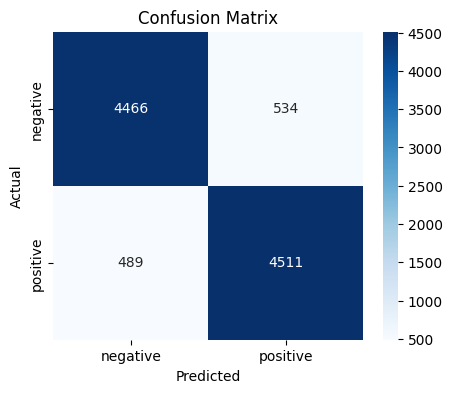


Review: This movie was absolutely fantastic, great acting and story!
Predicted Sentiment: Positive (97.6% confidence)


In [50]:
# ============================================================================
# SENTIMENT ANALYZER - TRAIN & EVALUATE
# Train-Test Split -> TF-IDF -> Logistic Regression -> Evaluation
# ============================================================================

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ---- 1. Convert labels to numeric (0 = negative, 1 = positive) ----
df['label'] = df['sentiment'].map({'negative': 0, 'positive': 1})

# ---- 2. Train-test split ----
X_train, X_test, y_train, y_test = train_test_split(
    df['processed_review'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

# ---- 3. TF-IDF Vectorization ----
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)
print("TF-IDF matrix shape (test):", X_test_tfidf.shape)

# ---- 4. Train Logistic Regression model ----
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# ---- 5. Predict on test set ----
y_pred = model.predict(X_test_tfidf)

# ---- 6. Evaluate ----
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["negative", "positive"]))

# ---- 7. Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["negative", "positive"],
            yticklabels=["negative", "positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ---- 8. Test on a custom review ----
def predict_sentiment(text):
    cleaned = preprocess_review(text)   # reuse your preprocessing function
    vector = tfidf.transform([cleaned])
    prediction = model.predict(vector)[0]
    probability = model.predict_proba(vector)[0]
    label = "Positive" if prediction == 1 else "Negative"
    confidence = max(probability) * 100
    return label, round(confidence, 2)

sample_review = "This movie was absolutely fantastic, great acting and story!"
label, confidence = predict_sentiment(sample_review)
print(f"\nReview: {sample_review}")
print(f"Predicted Sentiment: {label} ({confidence}% confidence)")

In [51]:
sample_review1 = "I did not like that Spider-Man movie. It was so basic and not very unique. It was just going in a simple flow."
label, confidence = predict_sentiment(sample_review1)
print(f"\nReview: {sample_review1}")
print(f"Predicted Sentiment: {label} ({confidence}% confidence)")


Review: I did not like that Spider-Man movie. It was so basic and not very unique. It was just going in a simple flow.
Predicted Sentiment: Positive (60.48% confidence)


In [52]:
# ============================================================================
# DEBUG: Inspect what words are driving this specific prediction wrong
# ============================================================================

sample_review1 = "I did not like that Spider-Man movie. It was so basic and not very unique. It was just going in a simple flow."

cleaned = preprocess_review(sample_review1)
print("Cleaned text:", cleaned)

vector = tfidf.transform([cleaned])
feature_names = tfidf.get_feature_names_out()

# Get the words actually present in this review (non-zero TF-IDF)
nonzero_idx = vector.nonzero()[1]
words_present = [(feature_names[i], vector[0, i], model.coef_[0][i]) for i in nonzero_idx]

# Sort by contribution = tfidf_value * coefficient (impact on the prediction)
words_present_sorted = sorted(words_present, key=lambda x: x[1]*x[2], reverse=True)

print(f"{'Word/Phrase':<20}{'TF-IDF':<10}{'Coefficient':<12}{'Contribution'}")
for word, tfidf_val, coef in words_present_sorted:
    contribution = tfidf_val * coef
    print(f"{word:<20}{tfidf_val:<10.4f}{coef:<12.4f}{contribution:.4f}")

print("\n(Positive contribution = pushes toward POSITIVE, Negative = pushes toward NEGATIVE)")
print("Sum of contributions + intercept determines final prediction")

Cleaned text: not like spider man movie. basic not very unique. going simple flow.
Word/Phrase         TF-IDF    Coefficient Contribution
unique              0.3231    3.0177      0.9749
simple              0.2890    2.6351      0.7615
not like            0.2965    1.7425      0.5166
very                0.1394    1.7040      0.2375
man                 0.1909    0.7291      0.1392
flow                0.3879    0.0336      0.0131
basic               0.3352    -0.0512     -0.0172
movie               0.0967    -0.4846     -0.0469
like                0.1179    -0.4681     -0.0552
going               0.1968    -0.4741     -0.0933
spider              0.4577    -0.7247     -0.3317
not                 0.1640    -3.0118     -0.4938
not very            0.3274    -3.5702     -1.1690

(Positive contribution = pushes toward POSITIVE, Negative = pushes toward NEGATIVE)
Sum of contributions + intercept determines final prediction
